# exp14: ETS bergulir sebagai pembanding pada PharmaSales

Notebook **pelapor**: menjelaskan eksperimen exp14 secara lengkap dengan membaca
berkas hasil yang sudah ada. Tidak melatih model, tidak menulis apa pun ke `results/`,
dan tidak mengimpor `src/experiments` maupun `tools`.

> **Hasil pokok: dua ramalan pra-registrasi GAGAL.** ETS bergulir ternyata *lebih akurat*
> daripada AR-LRX pada data obat harian. Ini dilaporkan apa adanya, bukan dihaluskan.

## 1. Ringkasan

**Pertanyaan yang dijawab.** Pemulusan eksponensial ETS / Holt-Winters adalah keluarga model
yang paling mapan dalam prediksi permintaan obat (Subbab 2.3.1), tetapi belum termasuk model
pembanding yang dilatih ulang. exp14 menutup celah itu dengan menguji bagaimana AR-LRX
dibandingkan dengan ETS bergulir satu langkah di bawah kontrak eksperimen yang sama.

**Ramalan pra-registrasi** (ditulis 26 September 2026, sebelum skrip dijalankan sekali pun;
`PREREG_exp10_exp13_exp14.md` bagian 4):

| | Bunyi ramalan | Hasil |
|---|---|---|
| **P5a** | AR-LRX [linear] tidak lebih buruk daripada ETS bergulir lebih dari 1% secara gabungan, pada data harian maupun mingguan | **GAGAL** pada data harian (+4,91%) |
| **P5b** | ETS bergulir tidak lebih akurat daripada ARIMA(5,1,0) bergulir pada data harian | **GAGAL** (ETS 4,27% lebih akurat) |

**Dipakai di mana.**

| Naskah | Bagian |
|---|---|
| Disertasi | Subbab 4.6.2 (dua paragraf penuh), **Tabel 4.11** baris "ETS bergulir satu langkah (exp14)", **Tabel 4.13** baris ETS, dan Subbab 4.7.1 (jawaban kuantitatif RQ1) |
| Paper IJIES | **tidak dipakai**, karena exp14 dijalankan setelah naskah ronde 2 dikirim |

## 2. Lingkungan

In [1]:
# Notebook pelapor: HANYA MEMBACA.
# Tidak melatih model, tidak mengimpor src/experiments atau tools (agar TensorFlow
# tidak ikut termuat), dan tidak pernah menulis ke results/, data/ atau raw/.
%matplotlib inline
from pathlib import Path
import ast, json, hashlib, datetime, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cari_root(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / "results").is_dir() and (c / "src" / "experiments").is_dir():
            return c
    raise RuntimeError("root repositori tidak ditemukan dari " + str(p))


ROOT = cari_root(Path.cwd().resolve())
RES = ROOT / "results"
n_berkas = sum(1 for f in RES.rglob("*") if f.is_file())

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.max_rows", 200)

print("Root repositori :", ROOT)
print("Folder hasil    :", RES.relative_to(ROOT), f"({n_berkas} berkas)")
print("Dijalankan      :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


def idn(x, d=2, tanda=False):
    """Format angka gaya Indonesia (koma desimal, titik ribuan)."""
    s = f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    if tanda and x > 0:
        s = "+" + s
    return s.replace("-", "\u2212")


def baca(nama, **kw):
    """Baca satu berkas di results/ sebagai DataFrame. Read-only."""
    f = RES / nama
    if not f.exists():
        raise FileNotFoundError(f"{nama} tidak ada di results/")
    return pd.read_csv(f, **kw)


def potongan(relpath, nama=None, awal=None, akhir=None):
    """Tampilkan potongan kode dengan membaca berkas sebagai TEKS.

    Memakai ``ast`` untuk menemukan batas fungsi/konstanta, sehingga modul
    eksperimen tidak perlu diimpor.
    """
    f = ROOT / relpath
    teks = f.read_text(encoding="utf-8")
    baris = teks.splitlines()
    if nama is not None:
        pohon = ast.parse(teks)
        ketemu = False
        for n in ast.walk(pohon):
            if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and n.name == nama:
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
            if isinstance(n, ast.Assign) and any(getattr(t, "id", None) == nama for t in n.targets):
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
        if not ketemu:
            raise KeyError(f"'{nama}' tidak ditemukan di {relpath}")
    awal = awal or 1
    akhir = akhir or len(baris)
    lebar = len(str(akhir))
    print(f"--- {relpath}:{awal}-{akhir} " + "-" * max(0, 74 - len(relpath)))
    for i in range(awal, akhir + 1):
        print(f"{str(i).rjust(lebar)} | {baris[i - 1]}")


def git(*args):
    """Jalankan perintah git read-only di root repositori."""
    try:
        r = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() if r.returncode == 0 else ""
    except Exception:
        return ""

Root repositori : I:\Shared drives\Riset S3\Experiment S3 Code\antgravity_riset\AR-LRX_hybrid-forecasting
Folder hasil    : results (179 berkas)
Dijalankan      : 2026-09-29 06:57


In [2]:
# Pembanding angka CSV terhadap angka yang tercetak di disertasi.
# Tidak ada angka yang dibetulkan di sini; ketidakcocokan hanya dilaporkan.
_cek = []


def cek(butir, nilai_csv, nilai_naskah, tol=0.005, d=4, rujukan=""):
    beda = abs(float(nilai_csv) - float(nilai_naskah))
    ok = beda <= tol
    _cek.append({
        "Butir": butir,
        "Rujukan naskah": rujukan,
        "Dari CSV": round(float(nilai_csv), d),
        "Di disertasi": float(nilai_naskah),
        "|selisih|": round(beda, 6),
        "Status": "COCOK" if ok else "TIDAK COCOK",
    })
    return ok


def laporan_cek():
    t = pd.DataFrame(_cek)
    n_ok = int((t.Status == "COCOK").sum())
    display(t)
    print()
    print(f"RINGKASAN: {n_ok} dari {len(t)} angka COCOK dengan naskah disertasi.")
    buruk = t[t.Status == "TIDAK COCOK"]
    if len(buruk):
        print()
        print("!" * 78)
        print("ADA ANGKA YANG TIDAK COCOK. Tidak dibetulkan di notebook ini.")
        print("Laporkan butir berikut sebelum notebook dipakai sebagai lampiran:")
        for _, r in buruk.iterrows():
            print(f"  - {r.Butir} ({r['Rujukan naskah']}): "
                  f"CSV {r['Dari CSV']} vs naskah {r['Di disertasi']}")
        print("!" * 78)
    else:
        print("Tidak ada selisih di luar toleransi pembulatan.")
    return t

## 3. Desain eksperimen

**Data.** PharmaSales (Kaggle, M. Zdravkovic), delapan kategori ATC
(M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06), dua granularitas (harian dan mingguan),
dua set fitur (`A_lag1` dan `B_rich`) → **32 konfigurasi**. Ketika jumlah lag yang dipilih
dari PACF data latih sama dengan 1, `B_rich` berubah menjadi identik dengan `A_lag1`;
karena itu 32 konfigurasi memuat **20 konfigurasi yang berbeda**, dan ringkasan gabungan
dilaporkan atas yang 20 itu.

**Pembagian data.** Kronologis 70/15/15, tanpa pengacakan (kontrak C1).

**Model yang dibandingkan.** ETS bergulir satu langkah; ditambah S₁ [linear],
AR-LRX [linear] dan ARIMA(5,1,0) bergulir yang **dihitung ulang** memakai kode analisis
exp12 yang tidak diubah, supaya uji Diebold–Mariano berpasangan dapat dilakukan pada
prediksi dari satu run yang sama.

**Grid ETS.** Hanya *error* aditif yang dipakai, karena deret ini memuat nilai nol sehingga
komponen multiplikatif tidak sah. Terdapat lima spesifikasi kandidat, yang dipilih hanya
berdasarkan RMSE data validasi (kontrak C3):

In [3]:
potongan("tools/exp14_pharma_ets.py", nama="SPECS")

--- tools/exp14_pharma_ets.py:64-65 -------------------------------------------------
64 | SPECS = [(None, False, None), ("add", False, None), ("add", True, None),
65 |          (None, False, "add"), ("add", True, "add")]


**Evaluasi bergulir (kontrak C7).** Bagian ini sering ditanyakan, sehingga kodenya
ditampilkan utuh. Parameter berupa bobot pemulusan dan keadaan awal ditaksir pada blok yang
sedang dilatih, yaitu data latih pada tahap *tuning* dan data latih ditambah data validasi
pada refit akhir (kontrak C6). Selanjutnya model di-*filter* atas deret teramati dengan
parameter yang sudah dikunci, sehingga setiap prediksi hanya memakai pengamatan sampai
$t-1$. Prosedur ini sama dengan ARIMA bergulir di exp12.

In [4]:
potongan("tools/exp14_pharma_ets.py", nama="ets_one_step")

--- tools/exp14_pharma_ets.py:77-84 -------------------------------------------------
77 | def ets_one_step(y, n_fit, n_end, spec, sp):
78 |     """Fit on y[:n_fit]; one-step-ahead predictions for positions n_fit..n_end-1.
79 |     Returns (predictions, converged flag of the maximum-likelihood fit)."""
80 |     res = _ets(y[:n_fit], spec, sp).fit(disp=False, maxiter=2000)
81 |     conv = bool(getattr(res, "mle_retvals", {}).get("converged", True))
82 |     full = _ets(y[:n_end], spec, sp).smooth(res.params)
83 |     pred = np.asarray(full.fittedvalues, dtype=float)[n_fit:n_end]
84 |     return np.maximum(pred, 0.0), conv


**Pemilihan spesifikasi dan pencatatan kegagalan.** Spesifikasi yang gagal difit dilewati
dan dicatat pada `n_failed`. Fit yang berhenti sebelum kriteria konvergensi optimiser tetap
dipakai bila prediksinya berhingga, lalu dihitung pada `n_nonconverged_val` dan
`final_fit_converged`. Kedua besaran itu dilaporkan secara terbuka.

In [5]:
potongan("tools/exp14_pharma_ets.py", nama="ets_row")

--- tools/exp14_pharma_ets.py:87-113 -------------------------------------------------
 87 | def ets_row(d: P.Dataset, sp: int) -> dict:
 88 |     t0 = time.time()
 89 |     y = d.y
 90 |     best, best_rmse, best_val, n_failed, n_nonconv = None, np.inf, None, 0, 0
 91 |     for spec in SPECS:
 92 |         try:
 93 |             vp, conv = ets_one_step(y, d.i_train_end, d.i_val_end, spec, sp)
 94 |             n_nonconv += int(not conv)
 95 |             if not np.all(np.isfinite(vp)):
 96 |                 raise ValueError("non-finite")
 97 |         except Exception:
 98 |             n_failed += 1
 99 |             continue
100 |         r = float(np.sqrt(np.mean((d.y_val - vp) ** 2)))
101 |         if r < best_rmse:                      # tie-break: first specification wins
102 |             best, best_rmse, best_val = spec, r, vp
103 |     test_pred, test_conv = ets_one_step(y, d.i_val_end, len(y), best, sp)
104 |     row = {"model": "ETS rolling 1-step", **d.describe(),
105 |   

**Metrik dan uji.** RMSE pada blok uji. Selisih gabungan memakai rata-rata geometris
rasio RMSE (Persamaan 3.18 disertasi):

$$\text{gabungan} = 100 \times \left( \exp\left( \overline{\ln \frac{\text{RMSE}_{\text{AR-LRX}}}{\text{RMSE}_{\text{pembanding}}}} \right) - 1 \right)$$

Nilai negatif berarti AR-LRX lebih akurat. Uji Diebold–Mariano berpasangan per
konfigurasi, dengan koreksi Benjamini–Hochberg untuk banyaknya uji.

**Kontrak yang berlaku.** C1 (split kronologis), C3 (penyetelan hanya pada validasi),
C6 (statistik ditaksir pada blok yang sedang dilatih), C7 (prediksi bergulir satu langkah),
seed 42, jumlah lag dari PACF data latih saja (C5).

## 4. Asal-usul hasil

Perintah asli, yang tidak dijalankan oleh notebook ini.

In [6]:
RUN_EXPERIMENT = False

PERINTAH = "python tools/exp14_pharma_ets.py"

if RUN_EXPERIMENT:
    print(">>", PERINTAH)
    r = subprocess.run(PERINTAH, shell=True, cwd=ROOT)
    print("kode keluar:", r.returncode)
else:
    print("RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.")
    print()
    print("Perintah asli yang menghasilkan berkas di results/:")
    print("   ", PERINTAH)
    print("   ", "python tools/exp14_pharma_ets.py --quick   # uji asap: 2 kategori saja")
    print()
    print("Dijalankan sebagai bagian dari tools/run_exp10_13_14.bat, langkah pertama.")
    print("Runtime asli: 5,1 menit pada mesin referensi Windows.")

RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.

Perintah asli yang menghasilkan berkas di results/:
    python tools/exp14_pharma_ets.py
    python tools/exp14_pharma_ets.py --quick   # uji asap: 2 kategori saja

Dijalankan sebagai bagian dari tools/run_exp10_13_14.bat, langkah pertama.
Runtime asli: 5,1 menit pada mesin referensi Windows.


In [7]:
# Asal-usul berkas hasil: perintah, commit, waktu run, runtime, versi pustaka.
meta = json.loads((RES / "exp14_pharma_ets.meta.json").read_text(encoding="utf-8"))
print("meta.json ------------------------------------------------------------")
print(json.dumps(meta, indent=2, ensure_ascii=False))

print()
print("Commit yang menambahkan berkas hasil ---------------------------------")
for spec in ["--format=%h  %ad  %s", ]:
    out = git("log", "-3", "--date=short", spec, "--", "results/exp14_pharma_ets.csv")
    print(out or "(riwayat git tidak terbaca)")

print()
print("Commit yang menambahkan skrip dan pra-registrasi ----------------------")
print(git("log", "-2", "--date=short", "--format=%h  %ad  %s", "--", "tools/exp14_pharma_ets.py") or "-")
print(git("log", "-2", "--date=short", "--format=%h  %ad  %s", "--", "PREREG_exp10_exp13_exp14.md") or "-")

meta.json ------------------------------------------------------------
{
  "experiment": "exp14_pharma_ets",
  "n_rows": 128,
  "protocol": {
    "split_ratios": [
      0.7,
      0.15,
      0.15
    ],
    "tuning": "validation-only, refit on train+val",
    "feature_sets": [
      "A_lag1",
      "B_rich"
    ]
  },
  "environment": {
    "python": "3.10.11",
    "platform": "Windows-10-10.0.22621-SP0",
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "seed": "42",
    "sklearn": "1.7.2",
    "xgboost": "3.2.0",
    "statsmodels": "0.14.6"
  }
}

Commit yang menambahkan berkas hasil ---------------------------------


3a642df  2026-09-26  Results of pre-registered exp10, exp13, exp14

Commit yang menambahkan skrip dan pra-registrasi ----------------------


b913709  2026-09-26  Pre-register exp10, exp13, exp14: design and predictions P4-P9


b913709  2026-09-26  Pre-register exp10, exp13, exp14: design and predictions P4-P9


Log run asli, bila masih ada di mesin ini.

In [8]:
# Log run asli. Diabaikan git (*.log), jadi hanya ada di mesin referensi.
log = RES / "logs" / "exp14.log"
if log.exists():
    teks = log.read_text(encoding="utf-8", errors="replace")
    print(f"results/logs/exp14.log  ({log.stat().st_size} bytes, "
          f"ditulis {datetime.datetime.fromtimestamp(log.stat().st_mtime):%Y-%m-%d %H:%M})")
    print("=" * 78)
    print(teks[-2400:])
else:
    print("results/logs/exp14.log tidak ada di klon ini (berkas *.log diabaikan git).")
    print("Timeline run tercatat di RESULTS_exp10_exp13_exp14.md:")
    print("  exp14 mulai sekitar 08:30, selesai sekitar 08:35 pada 26 September 2026 (UTC+8).")

results/logs/exp14.log  (2952 bytes, ditulis 2026-09-26 08:35)
1  (2.1 min)
  daily  R06    B_rich  (2.2 min)
  weekly M01AB  A_lag1  (2.4 min)
  weekly M01AB  B_rich  (2.6 min)
  weekly M01AE  A_lag1  (2.8 min)
  weekly M01AE  B_rich  (2.9 min)
  weekly N02BA  A_lag1  (3.1 min)
  weekly N02BA  B_rich  (3.3 min)
  weekly N02BE  A_lag1  (3.5 min)
  weekly N02BE  B_rich  (3.7 min)
  weekly N05B   A_lag1  (3.8 min)
  weekly N05B   B_rich  (4.0 min)
  weekly N05C   A_lag1  (4.2 min)
  weekly N05C   B_rich  (4.3 min)
  weekly R03    A_lag1  (4.6 min)
  weekly R03    B_rich  (4.7 min)
  weekly R06    A_lag1  (4.9 min)
  weekly R06    B_rich  (5.1 min)

AR-LRX [linear] against each reference, distinct configurations (negative pooled_pct = AR-LRX better):
                  reference granularity  n  arlrx_wins  sig_wins_bh  sig_losses_bh  pooled_pct
ARIMA(5,1,0) rolling 1-step       daily 10           5            2              0        0.43
ARIMA(5,1,0) rolling 1-step      weekly 10          

## 5. Hasil

In [9]:
raw = baca("exp14_pharma_ets.csv")
summ = baca("exp14_pharma_ets_summary.csv")
dm = baca("exp14_pharma_ets_dm.csv")

print(f"exp14_pharma_ets.csv        : {raw.shape[0]} baris x {raw.shape[1]} kolom")
print(f"Model                       : {sorted(raw.model.unique())}")
print(f"Granularitas                : {sorted(raw.granularity.unique())}")
print(f"Kategori ATC                : {sorted(raw.category.unique())}")
print(f"Set fitur                   : {sorted(raw.feature_set.unique())}")
print(f"Konfigurasi per model       : {len(raw) // raw.model.nunique()}")
print()
print("Ringkasan gabungan, 20 konfigurasi berbeda (pooled_pct negatif = AR-LRX lebih akurat):")
d = summ[summ.scope == "distinct"].copy()
d["pooled_pct"] = d.pooled_pct.round(2)
display(d.drop(columns="scope").reset_index(drop=True))

exp14_pharma_ets.csv        : 128 baris x 45 kolom
Model                       : ['AR-LRX [linear]', 'ARIMA(5,1,0) rolling 1-step', 'ETS rolling 1-step', 'S1 [linear]']
Granularitas                : ['daily', 'weekly']
Kategori ATC                : ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
Set fitur                   : ['A_lag1', 'B_rich']
Konfigurasi per model       : 32

Ringkasan gabungan, 20 konfigurasi berbeda (pooled_pct negatif = AR-LRX lebih akurat):


,reference,granularity,n,arlrx_wins,sig_wins_bh,sig_losses_bh,pooled_pct
0,"ARIMA(5,1,0) rolling 1-step",daily,10,5,2,0,0.43
1,"ARIMA(5,1,0) rolling 1-step",weekly,10,7,0,0,-1.86
2,ETS rolling 1-step,daily,10,1,0,6,4.91
3,ETS rolling 1-step,weekly,10,7,0,1,0.69
4,S1 [linear],daily,10,2,0,0,0.18
5,S1 [linear],weekly,10,2,0,0,0.38


### 5.1 Spesifikasi ETS yang terpilih

Inilah yang menjelaskan **mengapa** ETS menang pada data harian.

In [10]:
# Spesifikasi ETS yang terpilih pada data validasi, per granularitas.
ets = raw[raw.model == "ETS rolling 1-step"].copy()
spec = ets.params.map(lambda s: ast.literal_eval(s))
ets["trend"] = spec.map(lambda d: d["trend"])
ets["damped"] = spec.map(lambda d: d["damped"])
ets["seasonal"] = spec.map(lambda d: d["seasonal"])
ets["periode"] = spec.map(lambda d: d["seasonal_periods"])

tab = (ets.groupby(["granularity", "trend", "damped", "seasonal", "periode"], dropna=False)
          .size().rename("jumlah").reset_index())
display(tab)

har = ets[ets.granularity == "daily"]
n_musiman = int((har.seasonal == "add").sum())
n_musiman_teredam = int(((har.seasonal == "add") & (har.damped)).sum())
print()
print(f"Data harian: komponen musiman periode 7 terpilih pada {n_musiman} dari {len(har)} konfigurasi,")
print(f"dan pada {n_musiman_teredam} di antaranya bersama tren teredam.")
print()
print("Kegagalan fit dan konvergensi (dilaporkan, tidak disembunyikan):")
print(f"  spesifikasi gagal difit (n_failed)         : {int(np.nansum(pd.to_numeric(ets.n_failed, errors='coerce')))}")
print(f"  fit validasi tak konvergen (n_nonconverged): {int(np.nansum(pd.to_numeric(ets.n_nonconverged_val, errors='coerce')))}")
print(f"  fit akhir konvergen                        : "
      f"{int(ets.final_fit_converged.astype(str).str.lower().eq('true').sum())} dari {len(ets)}")

,granularity,trend,damped,seasonal,periode,jumlah
0,daily,add,False,NaN,NaN,2
1,daily,add,True,add,7.0,8
2,daily,add,True,NaN,NaN,2
3,daily,NaN,False,add,7.0,2
4,daily,NaN,False,NaN,NaN,2
5,weekly,add,False,NaN,NaN,4
6,weekly,add,True,NaN,NaN,4
7,weekly,NaN,False,add,52.0,2
8,weekly,NaN,False,NaN,NaN,6



Data harian: komponen musiman periode 7 terpilih pada 10 dari 16 konfigurasi,
dan pada 8 di antaranya bersama tren teredam.

Kegagalan fit dan konvergensi (dilaporkan, tidak disembunyikan):
  spesifikasi gagal difit (n_failed)         : 0
  fit validasi tak konvergen (n_nonconverged): 16
  fit akhir konvergen                        : 32 dari 32


### 5.2 Selisih per konfigurasi

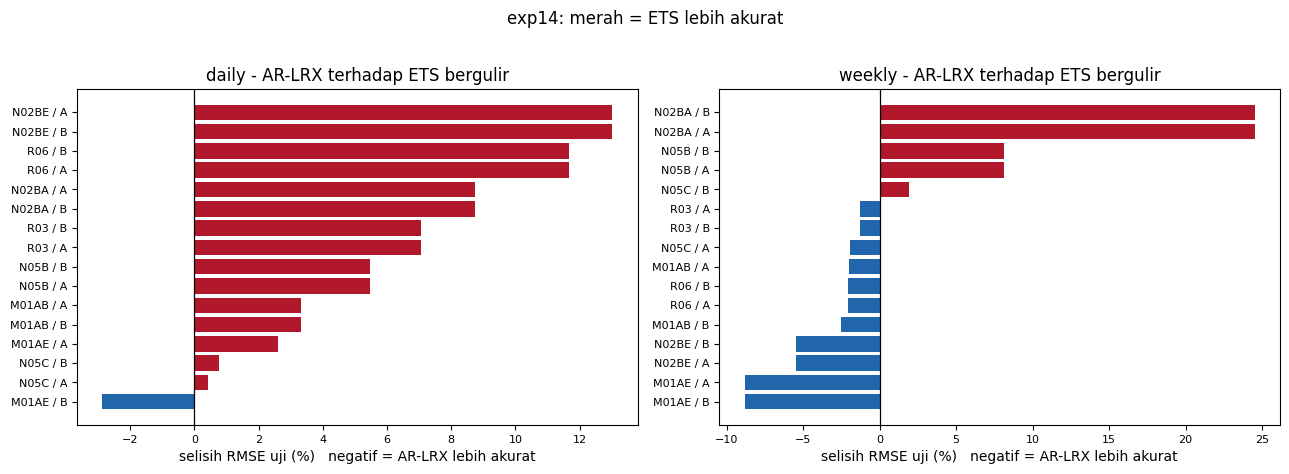

Jumlah konfigurasi yang dimenangkan AR-LRX (dari 16 per granularitas):
granularity
daily      1
weekly    11


In [11]:
# RMSE uji per konfigurasi: AR-LRX terhadap ETS.
piv = raw.pivot_table(index=["granularity", "category", "feature_set"],
                      columns="model", values="test_RMSE")
piv["selisih_%"] = 100 * (piv["AR-LRX [linear]"] / piv["ETS rolling 1-step"] - 1)
piv = piv.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=False)
for ax, g in zip(axes, ["daily", "weekly"]):
    s = piv[piv.granularity == g].copy()
    s["label"] = s.category + " / " + s.feature_set.str[0]
    s = s.sort_values("selisih_%")
    warna = ["#b2182b" if v > 0 else "#2166ac" for v in s["selisih_%"]]
    ax.barh(s.label, s["selisih_%"], color=warna)
    ax.axvline(0, color="black", lw=0.9)
    ax.set_title(f"{g} - AR-LRX terhadap ETS bergulir")
    ax.set_xlabel("selisih RMSE uji (%)   negatif = AR-LRX lebih akurat")
    ax.tick_params(labelsize=8)
fig.suptitle("exp14: merah = ETS lebih akurat", y=1.02)
fig.tight_layout()
plt.show()

print("Jumlah konfigurasi yang dimenangkan AR-LRX (dari 16 per granularitas):")
print(piv.groupby("granularity")["selisih_%"].apply(lambda s: int((s < 0).sum())).to_string())

### 5.3 Uji Diebold–Mariano terhadap ETS

In [12]:
# Uji Diebold-Mariano terhadap ETS, setelah koreksi Benjamini-Hochberg.
d = dm[(dm.reference == "ETS rolling 1-step") & (dm.distinct)].copy()
d["arah"] = np.where(d.delta_pct < 0, "AR-LRX lebih akurat", "ETS lebih akurat")
d["signifikan (BH)"] = np.where(d.p_bh < 0.05, "ya", "-")
tampil = d[["granularity", "category", "feature_set", "rmse_arlrx", "rmse_ref",
            "delta_pct", "p", "p_bh", "arah", "signifikan (BH)"]].copy()
for c in ["rmse_arlrx", "rmse_ref", "delta_pct"]:
    tampil[c] = tampil[c].round(3)
for c in ["p", "p_bh"]:
    tampil[c] = tampil[c].round(4)
display(tampil.sort_values(["granularity", "delta_pct"]).reset_index(drop=True))

print()
for g in ["daily", "weekly"]:
    s = d[d.granularity == g]
    kalah = int(((s.delta_pct > 0) & (s.p_bh < 0.05)).sum())
    menang = int(((s.delta_pct < 0) & (s.p_bh < 0.05)).sum())
    print(f"{g:7s}: {len(s)} konfigurasi berbeda, "
          f"AR-LRX menang signifikan {menang}, kalah signifikan {kalah} (setelah BH)")

,granularity,category,feature_set,rmse_arlrx,rmse_ref,delta_pct,p,p_bh,arah,signifikan (BH)
0,daily,M01AE,B_rich,2.198,2.263,-2.861,0.0710,0.1514,AR-LRX lebih akurat,-
1,daily,N05C,A_lag1,1.145,1.140,0.428,0.5104,0.6533,ETS lebih akurat,-
2,daily,N05C,B_rich,1.149,1.140,0.779,0.3632,0.5021,ETS lebih akurat,-
3,daily,M01AE,A_lag1,2.322,2.263,2.611,0.1983,0.3525,ETS lebih akurat,-
4,daily,M01AB,A_lag1,2.964,2.869,3.326,0.0043,0.0230,ETS lebih akurat,ya
5,daily,N05B,A_lag1,4.436,4.206,5.465,0.0162,0.0433,ETS lebih akurat,ya
6,daily,R03,A_lag1,8.347,7.797,7.058,0.0157,0.0433,ETS lebih akurat,ya
7,daily,N02BA,A_lag1,2.150,1.977,8.755,0.0001,0.0020,ETS lebih akurat,ya
8,daily,R06,A_lag1,2.546,2.280,11.666,0.0014,0.0112,ETS lebih akurat,ya
9,daily,N02BE,A_lag1,14.340,12.689,13.009,0.0066,0.0262,ETS lebih akurat,ya



daily  : 10 konfigurasi berbeda, AR-LRX menang signifikan 0, kalah signifikan 6 (setelah BH)
weekly : 10 konfigurasi berbeda, AR-LRX menang signifikan 0, kalah signifikan 1 (setelah BH)


## 6. Cek kecocokan dengan angka disertasi

Setiap angka exp14 yang tercetak di disertasi dibandingkan dengan angka yang dibaca
langsung dari CSV. Toleransi 0,005 mengakomodasi pembulatan dua desimal.
**Bila ada yang tidak cocok, notebook melaporkannya dan tidak membetulkannya.**

In [13]:
d = summ[summ.scope == "distinct"].set_index(["reference", "granularity"])
e12 = baca("exp12_pharma_baselines_summary.csv")
e12d = e12[e12.scope == "distinct"].set_index(["reference", "granularity"])

# --- Tabel 4.11, baris "ETS bergulir satu langkah (exp14)" -------------------
ets_h = d.loc[("ETS rolling 1-step", "daily")]
ets_m = d.loc[("ETS rolling 1-step", "weekly")]
cek("Tabel 4.11 ETS harian: AR-LRX menang", ets_h.arlrx_wins, 1, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 ETS harian: menang signifikan", ets_h.sig_wins_bh, 0, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 ETS harian: kalah signifikan", ets_h.sig_losses_bh, 6, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 ETS harian: gabungan (%)", ets_h.pooled_pct, 4.91, rujukan="Tabel 4.11 / Subbab 4.6.2")
cek("Tabel 4.11 ETS mingguan: AR-LRX menang", ets_m.arlrx_wins, 7, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 ETS mingguan: menang signifikan", ets_m.sig_wins_bh, 0, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 ETS mingguan: kalah signifikan", ets_m.sig_losses_bh, 1, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 ETS mingguan: gabungan (%)", ets_m.pooled_pct, 0.69, rujukan="Tabel 4.11 / Subbab 4.6.2")

# --- Subbab 4.6.2: ETS 4,27% lebih akurat daripada ARIMA bergulir (harian) ---
ar_h = d.loc[("ARIMA(5,1,0) rolling 1-step", "daily")]
rasio = (1 + ar_h.pooled_pct / 100) / (1 + ets_h.pooled_pct / 100) - 1
cek("Subbab 4.6.2: ETS vs ARIMA bergulir, harian (%)", 100 * rasio, -4.27, tol=0.01,
    rujukan="Subbab 4.6.2 / P5b")

# --- AR-LRX yang dihitung ulang di exp14 harus sama dengan exp12 -------------
for g, nilai in [("daily", 0.43), ("weekly", -1.86)]:
    cek(f"ARIMA bergulir {g}: gabungan (%) pada exp14",
        d.loc[("ARIMA(5,1,0) rolling 1-step", g)].pooled_pct, nilai, tol=0.006,
        rujukan="Subbab 4.6.2")
    cek(f"ARIMA bergulir {g}: exp14 sama dengan exp12",
        d.loc[("ARIMA(5,1,0) rolling 1-step", g)].pooled_pct,
        e12d.loc[("ARIMA(5,1,0) rolling 1-step", g)].pooled_pct, tol=1e-9,
        rujukan="catatan Tabel 4.11")
for g, nilai in [("daily", 0.18), ("weekly", 0.38)]:
    cek(f"S1 [linear] {g}: exp14 sama dengan exp12",
        d.loc[("S1 [linear]", g)].pooled_pct,
        e12d.loc[("S1 [linear]", g)].pooled_pct, tol=1e-9,
        rujukan="catatan Tabel 4.11")

# --- Subbab 4.6.2: spesifikasi terpilih --------------------------------------
cek("Subbab 4.6.2: konfigurasi harian dengan musiman periode 7", n_musiman, 10, tol=0,
    rujukan="Subbab 4.6.2")
cek("Subbab 4.6.2: di antaranya dengan tren teredam", n_musiman_teredam, 8, tol=0,
    rujukan="Subbab 4.6.2")

# --- Tabel 4.13 --------------------------------------------------------------
cek("Tabel 4.13 baris ETS: harian (%)", ets_h.pooled_pct, 4.91, rujukan="Tabel 4.13")
cek("Tabel 4.13 baris ETS: mingguan (%)", ets_m.pooled_pct, 0.69, rujukan="Tabel 4.13")

# --- Jumlah konfigurasi ------------------------------------------------------
cek("Jumlah konfigurasi berbeda", ets_h.n, 10, tol=0, rujukan="judul Tabel 4.11 (20 konfigurasi, 10 per granularitas)")
cek("Jumlah konfigurasi seluruhnya", summ[(summ.reference == "ETS rolling 1-step") &
    (summ.granularity == "daily") & (summ.scope == "all")].n.iloc[0], 16, tol=0,
    rujukan="32 konfigurasi, 16 per granularitas")

hasil_cek = laporan_cek()

,Butir,Rujukan naskah,Dari CSV,Di disertasi,|selisih|,Status
0,Tabel 4.11 ETS harian: AR-LRX menang,Tabel 4.11,1.0000,1.000000,0.000000,COCOK
1,Tabel 4.11 ETS harian: menang signifikan,Tabel 4.11,0.0000,0.000000,0.000000,COCOK
2,Tabel 4.11 ETS harian: kalah signifikan,Tabel 4.11,6.0000,6.000000,0.000000,COCOK
3,Tabel 4.11 ETS harian: gabungan (%),Tabel 4.11 / Subbab 4.6.2,4.9115,4.910000,0.001491,COCOK
4,Tabel 4.11 ETS mingguan: AR-LRX menang,Tabel 4.11,7.0000,7.000000,0.000000,COCOK
5,Tabel 4.11 ETS mingguan: menang signifikan,Tabel 4.11,0.0000,0.000000,0.000000,COCOK
6,Tabel 4.11 ETS mingguan: kalah signifikan,Tabel 4.11,1.0000,1.000000,0.000000,COCOK
7,Tabel 4.11 ETS mingguan: gabungan (%),Tabel 4.11 / Subbab 4.6.2,0.6876,0.690000,0.002379,COCOK
8,"Subbab 4.6.2: ETS vs ARIMA bergulir, harian (%)",Subbab 4.6.2 / P5b,-4.2722,-4.270000,0.002158,COCOK
9,ARIMA bergulir daily: gabungan (%) pada exp14,Subbab 4.6.2,0.4295,0.430000,0.000494,COCOK



RINGKASAN: 21 dari 21 angka COCOK dengan naskah disertasi.
Tidak ada selisih di luar toleransi pembulatan.


## 7. Pengujian ulang ramalan P5

In [14]:
# Ramalan P5 diuji ulang sesuai bunyinya di PREREG_exp10_exp13_exp14.md.
print("P5a. 'AR-LRX [linear] tidak lebih buruk daripada ETS bergulir lebih dari 1% secara")
print("      gabungan, pada data harian maupun mingguan (pooled_pct <= +1,0).'")
for g, v in [("harian", ets_h.pooled_pct), ("mingguan", ets_m.pooled_pct)]:
    status = "terpenuhi" if v <= 1.0 else "TIDAK TERPENUHI"
    print(f"      {g:9s}: pooled_pct = {idn(v, 2, tanda=True)}%  -> {status}")
print()
print("P5b. 'ETS bergulir tidak lebih akurat daripada ARIMA(5,1,0) bergulir pada data harian.")
print("      Rasio gabungan ETS/ARIMA >= 1.'")
# Keduanya diturunkan dari dua perbandingan AR-LRX pada ringkasan yang sama:
#   pooled_pct ETS   -> RMSE_AR-LRX / RMSE_ETS
#   pooled_pct ARIMA -> RMSE_AR-LRX / RMSE_ARIMA
# sehingga RMSE_ETS / RMSE_ARIMA = (1 + pct_ARIMA/100) / (1 + pct_ETS/100).
rasio_ets_arima = (1 + ar_h.pooled_pct / 100) / (1 + ets_h.pooled_pct / 100)
print(f"      RMSE(AR-LRX)/RMSE(ETS)   = {1 + ets_h.pooled_pct / 100:.6f}")
print(f"      RMSE(AR-LRX)/RMSE(ARIMA) = {1 + ar_h.pooled_pct / 100:.6f}")
print(f"      rasio ETS/ARIMA = {rasio_ets_arima:.4f}  -> "
      f"{'terpenuhi' if rasio_ets_arima >= 1 else 'TIDAK TERPENUHI'}")
print(f"      artinya ETS {idn(abs(100 * (rasio_ets_arima - 1)), 2)}% lebih akurat daripada ARIMA bergulir.")
print()
print("=" * 78)
print("KESIMPULAN: P5a GAGAL pada data harian, P5b GAGAL.")
print("Keduanya dilaporkan apa adanya di RESULTS_exp10_exp13_exp14.md dan di Subbab 4.6.2.")
print("Tidak ada parameter yang diubah setelah pra-registrasi dan tidak ada run yang diulang.")

P5a. 'AR-LRX [linear] tidak lebih buruk daripada ETS bergulir lebih dari 1% secara
      gabungan, pada data harian maupun mingguan (pooled_pct <= +1,0).'
      harian   : pooled_pct = +4,91%  -> TIDAK TERPENUHI
      mingguan : pooled_pct = +0,69%  -> terpenuhi

P5b. 'ETS bergulir tidak lebih akurat daripada ARIMA(5,1,0) bergulir pada data harian.
      Rasio gabungan ETS/ARIMA >= 1.'
      RMSE(AR-LRX)/RMSE(ETS)   = 1.049115
      RMSE(AR-LRX)/RMSE(ARIMA) = 1.004295
      rasio ETS/ARIMA = 0.9573  -> TIDAK TERPENUHI
      artinya ETS 4,27% lebih akurat daripada ARIMA bergulir.

KESIMPULAN: P5a GAGAL pada data harian, P5b GAGAL.
Keduanya dilaporkan apa adanya di RESULTS_exp10_exp13_exp14.md dan di Subbab 4.6.2.
Tidak ada parameter yang diubah setelah pra-registrasi dan tidak ada run yang diulang.


## 8. Interpretasi dan keterbatasan

**Yang ditunjukkan hasil ini.** Pada data obat harian, ETS musiman adalah model paling
akurat di antara seluruh pembanding yang diuji. AR-LRX tertinggal 4,91% secara gabungan,
dan ETS menang signifikan pada 6 dari 10 konfigurasi harian setelah koreksi
Benjamini–Hochberg. Pada data mingguan selisihnya kecil (+0,69%, satu kekalahan signifikan).

**Mengapa.** Spesifikasi yang terpilih menjawabnya sendiri: pada 10 dari 16 konfigurasi
harian ETS memilih komponen musiman berperiode 7, dan pada 8 di antaranya bersama tren
teredam. Pola hari-dalam-minggu, ditambah level yang diperbarui pada setiap pengamatan,
adalah struktur yang **tidak** ditangkap regresi linier atas lag. Jadi kekalahan ini
bukan kekalahan mekanisme koreksi residual, melainkan kekalahan **tahap pertamanya**.

**Kaitannya dengan pesan Bab IV.** Pesan utama Bab IV adalah bahwa pada kondisi residual
*noise*, akurasi ditentukan oleh seberapa baik tahap pertama menangkap struktur deret,
dan tidak oleh koreksi residual. Hasil exp14 sejalan dengan pesan tersebut.

**Keterbatasan yang harus disebut sendiri.**

1. exp14 tidak menyertakan ETS sebagai **tahap pertama** AR-LRX. Yang diuji hanya ETS
   sebagai model tunggal. Apakah AR-LRX dengan tahap pertama ETS akan menutup selisih itu
   belum diuji, dan itu jalur lanjutan yang paling jelas.
2. Tahap pertama berkalender pada exp11 menangkap sebagian struktur tersebut, tetapi
   secara eksploratif masih 2,27% di belakang ETS pada data harian dan 1,25% pada data
   mingguan. Angka ini **eksploratif**, tidak dipra-registrasi.
3. Lima spesifikasi ETS adalah grid yang sempit dibandingkan pencarian otomatis gaya
   `auto.ets`. Grid itu dikunci di muka pada pra-registrasi dan tidak diubah sesudahnya.
4. Hanya satu pembagian data dan satu seed. Ketahanan terhadap *forecast origin* diuji
   di exp07, tetapi exp07 tidak mencakup ETS.

## 9. Pertanyaan yang mungkin diajukan promotor

**1. "Kalau ETS lebih akurat, untuk apa AR-LRX?"**
Pada data harian univariat tanpa fitur kalender memang tidak, dan disertasi menyatakannya di
Subbab 4.7.1 serta Subbab 4.7.5 sebagai batas klaim. Klaim AR-LRX bersifat bersyarat. Model
ini menurunkan *error* secara bermakna bila residual tahap pertama masih berstruktur, yaitu
−5,45% terhadap pembanding terkuat pada Rossmann. Bila residualnya *noise*, pemburukannya
kecil, yaitu +0,18% pada data harian dan +0,38% pada data mingguan terhadap tahap pertamanya
sendiri (baris `S1 [linear]` pada bagian 5). Gerbang menahan pemburukan itu tetap kecil.

**2. "Apakah ETS diberi perlakuan yang adil, atau sengaja dilemahkan?"**
ETS diberi perlakuan yang sama dengan model lain. Pada kode `ets_one_step` di bagian 3
terlihat bahwa ETS memakai prediksi bergulir satu langkah seperti seluruh model lain
(kontrak C7). Parameternya ditaksir ulang pada data latih ditambah data validasi sebelum
data uji disentuh (C6), dan spesifikasinya dipilih hanya berdasarkan RMSE data validasi (C3).
Ketimpangan yang berlawanan arah telah dibetulkan oleh exp12, karena ARIMA di exp01
berjalan multi-langkah sehingga dirugikan.

**3. "Ramalannya gagal. Apa buktinya ramalan itu ditulis lebih dahulu?"**
Pra-registrasi berada pada commit tersendiri, yaitu `b913709`, yang ditambahkan pukul
08:27:13 pada 26 September 2026 dan di-*push* ke GitHub pukul 08:27:27. Waktu itu mendahului
awal run exp14 yang berlangsung sekitar pukul 08:30. Hasilnya di-*commit* terpisah pukul
19:11. Rangkaian waktu lengkapnya ada di `RESULTS_exp10_exp13_exp14.md`. Bagian "Deviations"
pada pra-registrasi kosong, karena tidak ada parameter yang diubah dan tidak ada run yang
diulang.

**4. "Angka mana di disertasi yang berasal dari eksperimen ini, dan sudah dicek?"**
Delapan angka pada Tabel 4.11 (baris ETS), dua pada Tabel 4.13, serta angka
4,27% dan pasangan 10/8 spesifikasi musiman pada Subbab 4.6.2. Seluruhnya diperiksa
otomatis di bagian 6 notebook ini terhadap `exp14_pharma_ets_summary.csv` dan
`exp14_pharma_ets.csv`, lengkap dengan status COCOK per angka.

**5. "Mengapa AR-LRX dihitung ulang di exp14, dan apakah hasilnya konsisten dengan exp12?"**
Tujuannya agar uji Diebold–Mariano berpasangan memakai prediksi dari satu run yang sama.
Membandingkan RMSE lintas run akan mencampurkan ketidakpastian numerik ke dalam uji.
Konsistensinya diperiksa pada bagian 6: nilai gabungan AR-LRX terhadap `S1 [linear]` dan
terhadap ARIMA bergulir di exp14 dibandingkan dengan nilai yang sama pada
`exp12_pharma_baselines_summary.csv`, dengan toleransi 1e-9.

---

### Ringkasan satu paragraf

exp14 menambahkan ETS bergulir satu langkah sebagai pembanding pada 32 konfigurasi
PharmaSales, di bawah kontrak eksperimen yang tidak diubah, dengan dua ramalan yang
ditulis dan di-*commit* sebelum skripnya dijalankan. Keduanya gagal: ETS 4,91% lebih
akurat daripada AR-LRX pada data harian dan 4,27% lebih akurat daripada ARIMA bergulir,
karena pada 10 dari 16 konfigurasi harian ETS memilih komponen musiman berperiode 7.
Pada data mingguan selisihnya kecil, yaitu +0,69%. Kegagalan kedua ramalan ini dilaporkan
apa adanya. Hasilnya sejalan dengan pesan utama Bab IV, bahwa pada kondisi residual *noise*
akurasi ditentukan oleh tahap pertama.